In [1]:
!pip install youtube-comment-downloader
"""
Script scraping komentar dari BANYAK VIDEO YouTube sekaligus,
tanpa API key, menggunakan 'youtube-comment-downloader'.

Cara pakai:
1. Install dependency:
   pip install youtube-comment-downloader

2. Isi daftar URL video di bagian VIDEO_URLS di bawah
   (satu URL per video, dipisah koma).

3. Jalankan:
   python scrape_banyak_video.py

Hasil:
- Semua komentar dari semua video akan digabung jadi satu file CSV
  (ada kolom tambahan 'video_url' supaya tahu komentar itu dari video mana)
"""

from youtube_comment_downloader import YoutubeCommentDownloader, SORT_BY_RECENT
import csv
import time

# ==== KONFIGURASI ====
VIDEO_URLS = [
    "https://youtu.be/HHNJNRrzb5A?si=NTl9fUpn-sjPDXJj",
    "https://youtu.be/WRxJGz-TA44?si=rfAIXKsyYvCPQPkk",

    # tambahkan sebanyak yang kamu mau di sini
]

OUTPUT_FILE = "komentar_banyak_video.csv"
LIMIT_PER_VIDEO = 300      # maksimal komentar per video (None = ambil semua)
JEDA_ANTAR_VIDEO = 8       # detik, biar tidak kena rate-limit dari YouTube


def scrape_one_video(downloader, video_url, limit=None):
    comments = []
    try:
        for i, comment in enumerate(downloader.get_comments_from_url(video_url, sort_by=SORT_BY_RECENT)):
            comments.append({
                "video_url": video_url,
                "author": comment.get("author"),
                "comment": comment.get("text"),
                "votes": comment.get("votes"),
                "time": comment.get("time"),
                "is_reply": comment.get("reply", False),
            })
            if limit and (i + 1) >= limit:
                break
    except Exception as e:
        print(f"  Gagal mengambil komentar dari {video_url}: {e}")

    return comments


def main():
    downloader = YoutubeCommentDownloader()
    semua_komentar = []

    for idx, url in enumerate(VIDEO_URLS):
        print(f"[{idx + 1}/{len(VIDEO_URLS)}] Mengambil komentar dari: {url}")
        hasil = scrape_one_video(downloader, url, limit=LIMIT_PER_VIDEO)
        print(f"  -> {len(hasil)} komentar didapat")
        semua_komentar.extend(hasil)

        # kasih jeda supaya tidak kena rate-limit, kecuali video terakhir
        if idx < len(VIDEO_URLS) - 1:
            time.sleep(JEDA_ANTAR_VIDEO)

    # simpan ke CSV
    if semua_komentar:
        with open(OUTPUT_FILE, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(
                f, fieldnames=["video_url", "author", "comment", "votes", "time", "is_reply"]
            )
            writer.writeheader()
            writer.writerows(semua_komentar)
        print(f"\nSelesai! Total {len(semua_komentar)} komentar dari {len(VIDEO_URLS)} video.")
        print(f"Tersimpan di: {OUTPUT_FILE}")
    else:
        print("\nTidak ada komentar yang berhasil diambil.")


if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 14.8 MB/s eta 0:00:00
[1/2] Mengambil komentar dari: https://youtu.be/HHNJNRrzb5A?si=NTl9fUpn-sjPDXJj
  -> 13 komentar didapat
[2/2] Mengambil komentar dari: https://youtu.be/WRxJGz-TA44?si=rfAIXKsyYvCPQPkk
  -> 258 komentar didapat

Selesai! Total 271 komentar dari 2 video.
Tersimpan di: komentar_banyak_video.csv


Membaca file: komentar_banyak_video.csv ...
Menyiapkan stemmer & stopword remover (Sastrawi)...
Memproses 271 komentar, mohon tunggu...
  ... 100/271 diproses
  ... 200/271 diproses
  ... 271/271 diproses

Hasil tersimpan di: hasil_segmentasi_sentimen.csv

=== RINGKASAN SENTIMEN ===
Positif   : 71 komentar (26.2%)
Netral    : 174 komentar (64.21%)
Negatif   : 26 komentar (9.59%)
Grafik tersimpan di: grafik_sentimen.png


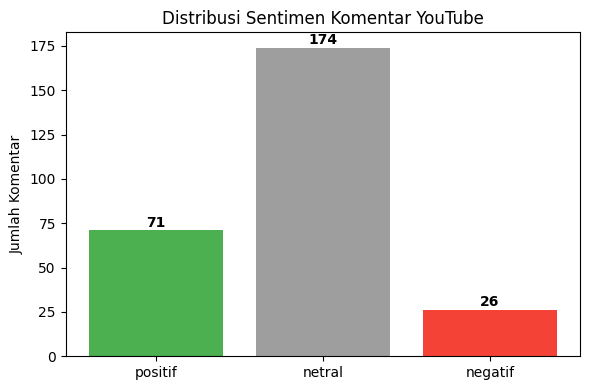

In [4]:
# -*- coding: utf-8 -*-

!pip install pandas Sastrawi matplotlib
"""
Script SEGMENTASI SENTIMEN untuk hasil scraping komentar YouTube.
Menggunakan pendekatan lexicon-based (kamus kata positif/negatif)
khusus Bahasa Indonesia, dilengkapi normalisasi kata gaul/slang
dan stemming pakai Sastrawi.

Cara pakai:
1. Install dependency:
   pip install pandas Sastrawi matplotlib

2. Pastikan kamu sudah punya file CSV hasil scraping
   (misal dari script sebelumnya: komentar_youtube.csv
   atau komentar_youtube_tanpa_api.csv / komentar_banyak_video.csv)

3. Ganti INPUT_FILE dan INPUT_COLUMN di bawah sesuai file & nama
   kolom komentarnya.

4. Jalankan:
   python segmentasi_sentimen.py

Output:
- File CSV baru berisi kolom tambahan: 'teks_bersih', 'skor_sentimen', 'sentimen'
- Ringkasan jumlah & persentase komentar positif/negatif/netral
- Grafik batang (bar chart) distribusi sentimen (disimpan sebagai .png)
"""

import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# ================== KONFIGURASI ==================
INPUT_FILE = "komentar_banyak_video.csv"   # ganti sesuai file hasil scraping kamu
INPUT_COLUMN = "comment"                         # nama kolom yang berisi teks komentar
OUTPUT_FILE = "hasil_segmentasi_sentimen.csv"
CHART_FILE = "grafik_sentimen.png"
GUNAKAN_STEMMING = True   # set False kalau data banyak & mau lebih cepat (stemming agak berat)

# ================== NORMALISASI KATA GAUL/SLANG ==================
# Kamus kecil untuk mengubah kata gaul jadi kata baku, supaya lebih akurat
# saat dicocokkan dengan kamus sentimen. Bisa kamu tambah sendiri sesuai kebutuhan.
KAMUS_SLANG = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "gpp": "tidak apa apa", "gapapa": "tidak apa apa",
    "bgt": "banget", "bgttt": "banget", "bgtt": "banget",
    "yg": "yang", "dgn": "dengan", "krn": "karena", "karna": "karena",
    "udh": "sudah", "udah": "sudah", "dah": "sudah",
    "blm": "belum", "belom": "belum",
    "jd": "jadi", "jgn": "jangan", "jngn": "jangan",
    "tp": "tapi", "tpi": "tapi",
    "sy": "saya", "aq": "aku", "gw": "saya", "gue": "saya", "gua": "saya",
    "km": "kamu", "kmu": "kamu", "lu": "kamu", "loe": "kamu",
    "bs": "bisa", "bsa": "bisa",
    "trs": "terus", "trus": "terus",
    "skrg": "sekarang", "skarang": "sekarang",
    "bnyk": "banyak", "byk": "banyak",
    "org": "orang", "orng": "orang",
    "mantul": "mantap betul", "kece": "keren", "keren banget": "keren sekali",
    "anjay": "wow", "mantap jiwa": "mantap sekali",
    "parah": "berlebihan", "gila": "luar biasa",
}

# ================== KAMUS SENTIMEN ==================
# Daftar kata dasar bahasa Indonesia yang umum menunjukkan sentimen
# positif dan negatif pada komentar sosial media / YouTube.
KATA_POSITIF = set("""
bagus baik hebat mantap keren luar biasa suka cinta indah cantik ganteng
lucu senang bahagia gembira puas semangat sukses berhasil terbaik favorit
recommended rekomendasi menarik seru asik enak nikmat mantul top oke ok
setuju benar tepat sempurna hebatnya kagum salut bangga terima kasih
makasih thanks thankyou apik top markotop juara jago pintar cerdas rapi
membantu bermanfaat inspiratif inspiring motivasi menghibur menyenangkan
ramah sopan cepat tanggap murah worth worthit puas banget the best terbagus
istimewa unggul unik kreatif inovatif keren banget top banget joss josss
mantap sekali sangat bagus sangat suka sangat membantu
""".split())

KATA_NEGATIF = set("""
buruk jelek parah payah gagal kecewa marah benci sedih kesal jengkel
lambat mahal rusak error bohong palsu tipu penipu curang culas kasar
sombong bodoh goblok tolol bego norak alay lebay berisik ribet susah
sulit membosankan bosan capek lelah stress stres pusing sakit hati
mengecewakan menyesal nyesel rugi merugikan bahaya berbahaya salah
ancur hancur amburadul kacau berantakan males malas ogah nolak menolak
plin plan munafik hipokrit fitnah hoax hoaks spam scam palsu abal abal
zonk mengerikan menjijikkan jijik ngeselin nyebelin annoying worst
terburuk sangat buruk sangat jelek sangat mengecewakan parah banget
""".split())


def normalisasi_teks(teks):
    """Bersihkan dan normalisasi teks komentar."""
    if not isinstance(teks, str):
        return ""

    teks = teks.lower()
    teks = re.sub(r"http\S+|www\S+", " ", teks)          # hapus URL
    teks = re.sub(r"@\w+", " ", teks)                     # hapus mention
    teks = re.sub(r"#\w+", " ", teks)                     # hapus hashtag
    teks = re.sub(r"[^a-zA-Z\s]", " ", teks)               # hapus angka & simbol
    teks = re.sub(r"\s+", " ", teks).strip()               # rapikan spasi

    # normalisasi kata gaul/slang
    kata_kata = teks.split()
    kata_kata = [KAMUS_SLANG.get(k, k) for k in kata_kata]
    teks = " ".join(kata_kata)

    return teks


def hitung_sentimen(teks_bersih, stemmer, stopword_remover):
    """Hitung skor sentimen berdasarkan kamus positif/negatif."""
    teks_stop = stopword_remover.remove(teks_bersih)

    if GUNAKAN_STEMMING:
        teks_final = stemmer.stem(teks_stop)
    else:
        teks_final = teks_stop

    kata_kata = teks_final.split()

    skor_positif = sum(1 for k in kata_kata if k in KATA_POSITIF)
    skor_negatif = sum(1 for k in kata_kata if k in KATA_NEGATIF)
    skor_total = skor_positif - skor_negatif

    if skor_total > 0:
        label = "positif"
    elif skor_total < 0:
        label = "negatif"
    else:
        label = "netral"

    return teks_final, skor_total, label


def buat_grafik(df, filename):
    """Buat bar chart distribusi sentimen."""
    jumlah = df["sentimen"].value_counts().reindex(
        ["positif", "netral", "negatif"], fill_value=0
    )

    warna = {"positif": "#4CAF50", "netral": "#9E9E9E", "negatif": "#F44336"}
    plt.figure(figsize=(6, 4))
    bars = plt.bar(jumlah.index, jumlah.values, color=[warna[i] for i in jumlah.index])

    for bar in bars:
        tinggi = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, tinggi + 0.5, str(int(tinggi)),
                  ha="center", va="bottom", fontweight="bold")

    plt.title("Distribusi Sentimen Komentar YouTube")
    plt.ylabel("Jumlah Komentar")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    print(f"Grafik tersimpan di: {filename}")


def main():
    print(f"Membaca file: {INPUT_FILE} ...")
    df = pd.read_csv(INPUT_FILE)

    if INPUT_COLUMN not in df.columns:
        print(f"ERROR: Kolom '{INPUT_COLUMN}' tidak ditemukan di file.")
        print(f"Kolom yang tersedia: {list(df.columns)}")
        return

    print("Menyiapkan stemmer & stopword remover (Sastrawi)...")
    stemmer = StemmerFactory().create_stemmer()
    stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

    hasil_teks_bersih = []
    hasil_skor = []
    hasil_label = []

    total = len(df)
    print(f"Memproses {total} komentar, mohon tunggu...")

    for i, teks_asli in enumerate(df[INPUT_COLUMN]):
        teks_bersih_awal = normalisasi_teks(teks_asli)
        teks_final, skor, label = hitung_sentimen(teks_bersih_awal, stemmer, stopword_remover)

        hasil_teks_bersih.append(teks_final)
        hasil_skor.append(skor)
        hasil_label.append(label)

        if (i + 1) % 100 == 0 or (i + 1) == total:
            print(f"  ... {i + 1}/{total} diproses")

    df["teks_bersih"] = hasil_teks_bersih
    df["skor_sentimen"] = hasil_skor
    df["sentimen"] = hasil_label

    df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)
    print(f"\nHasil tersimpan di: {OUTPUT_FILE}")

    # ringkasan
    ringkasan = df["sentimen"].value_counts()
    persen = (df["sentimen"].value_counts(normalize=True) * 100).round(2)

    print("\n=== RINGKASAN SENTIMEN ===")
    for label in ["positif", "netral", "negatif"]:
        jml = ringkasan.get(label, 0)
        pct = persen.get(label, 0)
        print(f"{label.capitalize():10}: {jml} komentar ({pct}%)")

    buat_grafik(df, CHART_FILE)


if __name__ == "__main__":
    main()